cav.study_mesh_convergence(
    h=25, p=3, p_passes=3, p_step=1,
    n_modes=4, polarisation=('monopole',),
    max_refinements=6, max_ndof=80000,
)
df = cav.convergence_df_data
df[['p', 'h_pass', 'No of DOFs', 'freq [MHz]', 'max_err']].head(12)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jn_zeros
from cavsim2d import Pillbox
from cavsim2d.utils.style import apply_style, WARM
from cavsim2d.constants import c0
apply_style()

## 1. A cylinder with a known answer

The TM$_{010}$ frequency of a cylinder of radius $R$ is $f = c_0\,\chi_{01} / (2\pi R)$, with $\chi_{01}=2.405$ the first zero of $J_0$ — independent of the length.

In [2]:
R, L = 230.0, 200.0                         # mm
chi01 = jn_zeros(0, 1)[0]
f_analytic = c0 * chi01 / (2 * np.pi * R * 1e-3) * 1e-6   # MHz
print(f'analytic TM010 = {f_analytic:.4f} MHz')

cav = Pillbox(1, [L, R, 1.0, 0.0, 0.0], beampipe='none')  # closed cylinder
cav.name = 'cylinder'

analytic TM010 = 498.8806 MHz


## 2. Run the convergence sweep

Solve the monopole modes at polynomial orders $p = 3, 4, 5$; at each order the mesh is adaptively h-refined from a coarse `h = 25` mm start until the modes stop moving (or the DOF cap is hit). This is the slow cell.

In [3]:
cav.study_mesh_convergence(
    h=25, p=3, p_passes=3, p_step=1,
    n_modes=4, polarisation=('monopole',),
    max_refinements=6, max_ndof=80000,
)
df = cav.convergence_df_data
df[['p', 'h_pass', 'No of DOFs', 'freq [MHz]', 'max_err']].head(12)

,p,h_pass,No of DOFs,freq [MHz],max_err
0,3,0,6233,498.880621,2.081788e-09
1,3,0,6233,900.335461,1.966179e-06
2,3,0,6233,1092.504778,9.820737e-10
3,3,0,6233,1145.139417,4.132914e-06
4,3,0,6233,1368.600556,7.178823e-05
5,3,0,6233,1582.909132,7.117722e-04
6,3,1,10634,498.880621,2.951449e-10
7,3,1,10634,900.335454,2.767574e-07
8,3,1,10634,1092.504778,8.757307e-11
9,3,1,10634,1145.139400,9.635047e-07


## 3. Spectral convergence of the fundamental

Plot the fundamental's relative error against the analytic value versus the number of degrees of freedom, one curve per polynomial order. Higher $p$ reaches a given accuracy on far fewer DOFs — the hallmark of a high-order method.

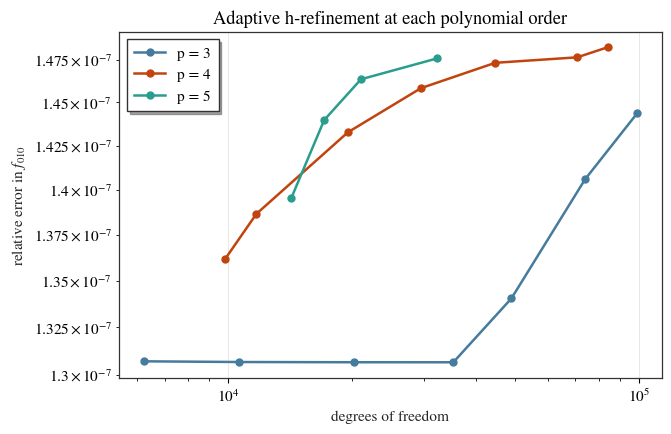

In [4]:
fund = df[df['mode_index'] == '0-0'].copy()
fund['rel_err'] = (fund['freq [MHz]'] - f_analytic).abs() / f_analytic

fig, ax = plt.subplots(figsize=(7, 4.5))
for i, (p, g) in enumerate(fund.groupby('p')):
    g = g.sort_values('No of DOFs')
    ax.plot(g['No of DOFs'], g['rel_err'], marker='o', ms=5,
            color=WARM[i % len(WARM)], label=f'p = {p}')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('degrees of freedom'); ax.set_ylabel('relative error in $f_{010}$')
ax.set_title('Adaptive h-refinement at each polynomial order')
ax.legend()
plt.show()

## 4. How fine is fine enough?

The best frequency reached at each order — for this cavity, cubic elements ($p=3$) hit part-per-million accuracy with a modest mesh.

In [5]:
best = fund.sort_values('rel_err').groupby('p').first()
best[['No of DOFs', 'freq [MHz]', 'rel_err']]

,No of DOFs,freq [MHz],rel_err
p,,,
3,35312,498.880621,1.306595e-07
4,9831,498.880624,1.361825e-07
5,14245,498.880625,1.395498e-07


## Where to go next

- [The pillbox / circular waveguide](pillbox.ipynb) — the same cylinder, checked against the closed form for 900 modes.
- [The TESLA elliptical cavity](elliptical_tesla.ipynb) — figures of merit on a converged mesh.
- Pass `mesh_config={'h':..., 'p':..., 'adaptive': True}` to any `cav.eigenmode.run(...)` to refine a single solve adaptively.